# 25 Weekly DMOs -> Fatigue

In [1]:
from src.patient_data_dispatcher import PatientDataDispatcher
from src.core.enums import MileStone, DataFrequency, PatientDataType
from src.pipeline import dmo_for_random_forest
from src.model import DMORandomForestRegressor
from src.evaluation import Evaluation

import torch

In [2]:
dmo_features = [
    "wb_all_sum",
    "walkdur_all_sum",
    "wbsteps_all_sum",
    "wbdur_all_avg",
    "wbdur_all_p90",
    "wbdur_all_var",
    "cadence_all_avg",
    "strdur_all_avg",
    "cadence_all_var",
    "strdur_all_var",
    "ws_1030_avg",
    "strlen_1030_avg",
    "wb_10_sum",
    "ws_10_p90",
    "wb_30_sum",
    "ws_30_avg",
    "strlen_30_avg",
    "cadence_30_avg",
    "strdur_30_avg",
    "ws_30_p90",
    "cadence_30_p90",
    "ws_30_var",
    "strlen_30_var",
    "wb_60_sum",
    "total_worn_h",
]

In [3]:
static_features = [
    "weight",
    "height",
    "EDFSCR1L"
]

In [4]:
pdd = PatientDataDispatcher(
    "config/config.yaml",
    dmo_features,
    MileStone.ALL,
    data_frequency=DataFrequency.DAILY,
    physical_subset=True,
    #static_features=static_features
)
ids = list(set(pdd.metadata["Local.Participant"].to_list()))
dmo_data, dmo_labels = pdd.get_patient_data(PatientDataType.MILESTONE, ids=ids)

In [5]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# perform impute on a visit by visit basis, as some visits are completely missing
imputer = IterativeImputer(missing_values=-1, tol=1e-2, keep_empty_features=True)
patients, visits, features, days = dmo_data.shape

for p in range(patients):
    for v in range(visits):
        visit_data = dmo_data[p, v]

        if (visit_data == -1).all():
            continue

        dmo_data[p, v] = torch.from_numpy(imputer.fit_transform(visit_data)).to(dtype=torch.float64)

/home/gwilym-rutherford/Documents/Year 3 Tuos/dissertation/Workspace/Experiment 1/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [6]:
# remove patients that don't have a full dataset
patient_indexs = []
patient, visit, days, features = dmo_data.shape
for p in range(patient):
    all_visits = True
    for v in range(visit):
        data = dmo_data[p, v]
        label = dmo_labels[p, v]
        if (data == -1.0).any() or label == -1.0:
            all_visits = False

    if all_visits:
        patient_indexs.append(p)

dmo_data = dmo_data[patient_indexs]
dmo_labels = dmo_labels[patient_indexs]

In [7]:
print(dmo_data.shape)

torch.Size([280, 5, 7, 25])


In [8]:
# flatten to weekly summaries (this keeps patients consistent over the testing)
dmo_data = dmo_data.mean(axis=2)

In [9]:
transforms = (None, None)
train, test = dmo_for_random_forest(dmo_data, dmo_labels, transforms, normalise=True)

train_input, train_label = train
test_input, test_label = test

In [10]:
patient, visit, features = train_input.shape
train_input = train_input.reshape(patient * visit, features)
train_label = train_label.reshape(patient * visit)

patient, visit, features = test_input.shape
test_input = test_input.reshape(patient * visit, features)
test_label = test_label.reshape(patient * visit)

In [11]:
print(train_input.shape)
print(train_label.shape)

torch.Size([1120, 25])
torch.Size([1120])


In [12]:
rf_model = DMORandomForestRegressor(n_trees=500)

rf_model.train(train_input, train_label)
score = rf_model.score(test_input, test_label)
print(score)


-0.048235990029987796


{'accuracy': 0.275, 'Mean Squared Error': 0.05872919782996178, 'Mean Absolute Error': 0.20117798447608948, 'R^2': -0.04823599002998891}


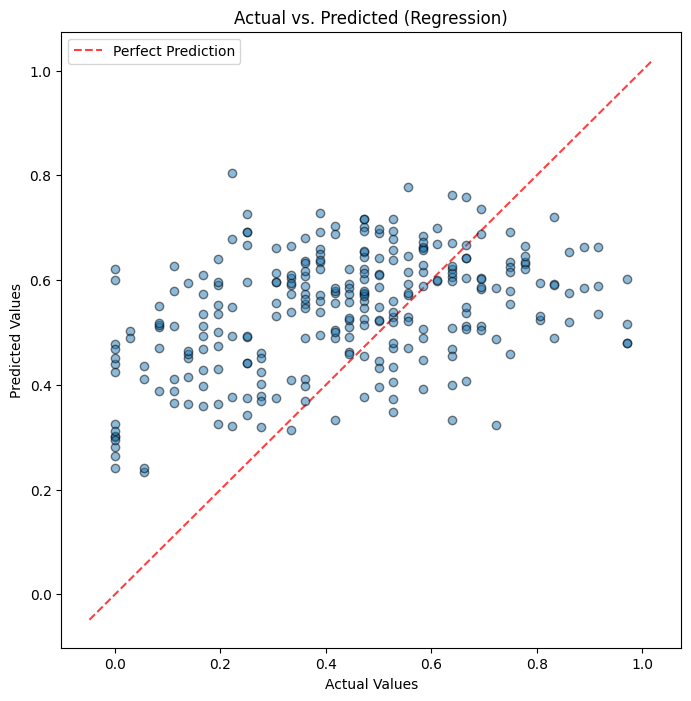

In [13]:
prediction = torch.tensor(rf_model.predict(test_input))
actual = test_label
evaluation = Evaluation(prediction, actual)
print(evaluation.compute_all_metrics())
evaluation.evaluation_plot().show()

/home/gwilym-rutherford/Documents/Year 3 Tuos/dissertation/Workspace/Experiment 1/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


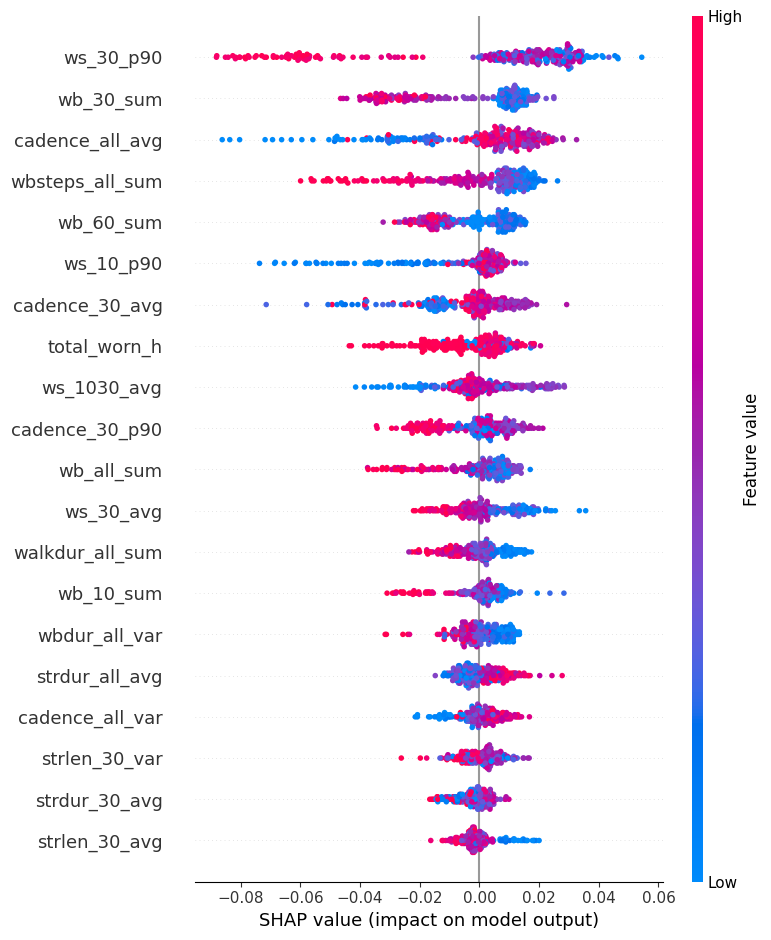

In [14]:
import shap

random_forest_model = rf_model.random_forest
test_input_numpy = torch.Tensor.numpy(test_input)

dmo_features = dmo_features + static_features

explainer = shap.TreeExplainer(random_forest_model)
shap_values = explainer.shap_values(test_input_numpy)
shap.summary_plot(shap_values, test_input_numpy, feature_names=dmo_features)